# Minería de datos: readmisión hospitalaria de pacientes diabéticos

**Dataset:** *Diabetes 130-US hospitals for years 1999–2008* (`diabetic_data.csv` + `IDS_mapping.csv`).
**Guía metodológica:** Witten, Frank & Hall — *Data Mining: Practical Machine Learning Tools and Techniques*, 3ª ed. (`DM3.pdf`).

El notebook sigue el recorrido del libro:

| Sección | Capítulo DM3 | Contenido |
|---|---|---|
| 1 | Cap. 1 – *What's it all about?* | Definición del problema y del concepto a aprender |
| 2 | Cap. 2 – *Input: concepts, instances, attributes* | Instancias, tipos de atributo, valores faltantes e inexactos |
| 3 | Cap. 2.4 – *Getting to know your data* | Análisis exploratorio |
| 4 | Cap. 7 – *Data transformations* | Limpieza, ingeniería y selección de atributos, discretización |
| 5 | Cap. 4 – *Algorithms: the basic methods* | ZeroR, 1R, Naive Bayes, árboles, reglas, modelos lineales, k-NN |
| 6 | Cap. 5 – *Credibility: evaluating what's been learned* | Validación cruzada estratificada, t-test pareado, costos, ROC, lift, precisión-recall |
| 7 | Cap. 8 – *Ensemble learning* | Bagging, Random Forest, Boosting |
| 8 | Cap. 4.5 – *Mining association rules* | Apriori |
| 9 | Cap. 4.8 / 6.8 – *Clustering* | k-means |
| 10 | — | Conclusiones |

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.cluster import KMeans
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score, silhouette_score)

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", palette="deep")
SEED = 42

## 1. El problema (Cap. 1)

El libro define la minería de datos como *"el proceso de descubrir patrones en los datos"*, patrones que deben ser **significativos** y conducir a alguna ventaja. Aquí la ventaja es clínica y económica: las readmisiones hospitalarias tempranas (< 30 días) son costosas y en EE. UU. se penalizan.

**Concepto a aprender (Cap. 2.1):** aprendizaje de **clasificación** — dado un encuentro hospitalario de un paciente diabético, predecir si será readmitido en menos de 30 días.
También se aplican los otros tres estilos de aprendizaje que describe el libro: **asociación** (sección 8), **clustering** (sección 9) y, de forma implícita, predicción numérica no es el objetivo.

## 2. La entrada: concepto, instancias y atributos (Cap. 2)

### 2.1 Carga de datos
En este dataset los faltantes se codifican con `?`. Además, el valor `None` en `max_glu_serum` y `A1Cresult` significa *"prueba no realizada"*, **no** un faltante — el libro (Cap. 2.4, *Missing values*) insiste en averiguar si un faltante tiene significado propio. Por eso se desactiva la conversión automática de `None`/`NA` a NaN.

In [2]:
df = pd.read_csv("diabetic_data.csv", na_values=["?"], keep_default_na=False)
print("Instancias:", df.shape[0], "| Atributos:", df.shape[1])
df.head()

Instancias: 101766 | Atributos: 50


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


### 2.2 Tablas de mapeo de IDs
`IDS_mapping.csv` contiene tres tablas apiladas (tipo de admisión, destino al alta y fuente de admisión). Se separan para dar nombre a los códigos nominales.

In [3]:
def load_mappings(path="IDS_mapping.csv"):
    maps, current, key = {}, None, None
    for line in open(path, encoding="utf-8"):
        line = line.strip()
        if not line or line == ",":
            current = None; continue
        k, v = line.split(",", 1)
        if current is None:           # línea de encabezado
            key = k; maps[key] = {}; current = maps[key]; continue
        current[int(k)] = v.strip().strip('"')
    return maps

maps = load_mappings()
for k, m in maps.items():
    print(f"{k}: {len(m)} códigos")

admission_type_id: 8 códigos
discharge_disposition_id: 30 códigos
admission_source_id: 25 códigos


### 2.3 Tipos de atributo
El libro distingue atributos **nominales**, **ordinales**, de **intervalo** y de **razón** (Cap. 2.3). Clasificamos los 50 atributos:

In [4]:
ids       = ["encounter_id", "patient_nbr"]
nominal   = ["race", "gender", "admission_type_id", "discharge_disposition_id", "admission_source_id",
             "payer_code", "medical_specialty", "diag_1", "diag_2", "diag_3", "change", "diabetesMed"]
ordinal   = ["age", "weight", "max_glu_serum", "A1Cresult"]
meds      = df.columns[df.columns.get_loc("metformin"): df.columns.get_loc("metformin-pioglitazone") + 1].tolist()
numeric   = ["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
             "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses"]
target    = "readmitted"

summary = pd.DataFrame({
    "tipo": (["id"]*len(ids) + ["nominal"]*len(nominal) + ["ordinal"]*len(ordinal)
             + ["ordinal (medicamento: No/Down/Steady/Up)"]*len(meds) + ["numérico (razón)"]*len(numeric) + ["clase"]),
}, index=ids + nominal + ordinal + meds + numeric + [target])
summary["valores_distintos"] = [df[c].nunique() for c in summary.index]
summary["% faltantes"] = [round(df[c].isna().mean() * 100, 2) for c in summary.index]
summary

,tipo,valores_distintos,% faltantes
encounter_id,id,101766,0.00
patient_nbr,id,71518,0.00
race,nominal,5,2.23
gender,nominal,3,0.00
admission_type_id,nominal,8,0.00
discharge_disposition_id,nominal,26,0.00
admission_source_id,nominal,17,0.00
payer_code,nominal,17,39.56
medical_specialty,nominal,72,49.08
diag_1,nominal,716,0.02


### 2.4 Valores faltantes (Cap. 2.4 *Missing values*)

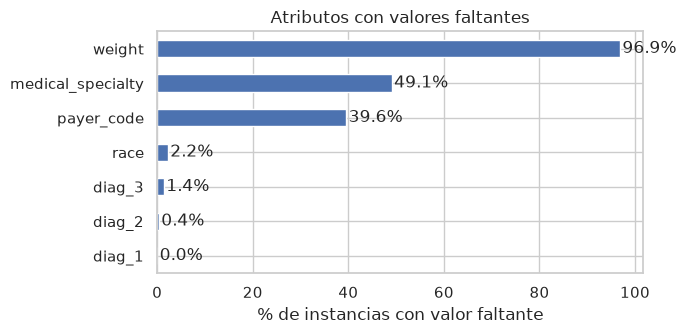

In [5]:
miss = df.isna().mean().mul(100).sort_values(ascending=False)
miss = miss[miss > 0]
ax = miss.plot.barh(figsize=(7, 3.5), color="C0")
ax.set_xlabel("% de instancias con valor faltante"); ax.invert_yaxis()
for i, v in enumerate(miss): ax.text(v + 0.5, i, f"{v:.1f}%", va="center")
plt.title("Atributos con valores faltantes"); plt.tight_layout(); plt.show()

**Decisiones:**
- `weight` (≈97 % faltante): se **elimina**; no aporta información fiable.
- `payer_code` (≈40 %) y `medical_specialty` (≈49 %): el faltante puede ser informativo (p. ej. especialidad no registrada), así que se conservan con la categoría explícita `Missing`, como sugiere el libro para faltantes "con significado".
- `race`, `diag_*`: pocos faltantes → categoría `Missing`.

### 2.5 Valores inexactos o inconsistentes (Cap. 2.4 *Inaccurate values*)

In [6]:
print("gender:", df.gender.value_counts().to_dict())
expired = [11, 19, 20, 21]
print("Encuentros donde el paciente falleció (discharge 11/19/20/21):", df.discharge_disposition_id.isin(expired).sum())
print("  …de ellos marcados como readmitidos:", (df.discharge_disposition_id.isin(expired) & (df.readmitted != "NO")).sum())
print("Encuentros por paciente — máx:", df.patient_nbr.value_counts().max(),
      "| pacientes con >1 encuentro:", (df.patient_nbr.value_counts() > 1).sum())
print("Atributos constantes o casi constantes:")
for c in meds:
    top = df[c].value_counts(normalize=True).iloc[0]
    if top > 0.999: print(f"   {c}: {top:.4%} = '{df[c].mode()[0]}'")

gender: {'Female': 54708, 'Male': 47055, 'Unknown/Invalid': 3}
Encuentros donde el paciente falleció (discharge 11/19/20/21): 1652
  …de ellos marcados como readmitidos: 0
Encuentros por paciente — máx: 40 | pacientes con >1 encuentro: 16773
Atributos constantes o casi constantes:
   chlorpropamide: 99.9155% = 'No'
   acetohexamide: 99.9990% = 'No'
   tolbutamide: 99.9774% = 'No'
   miglitol: 99.9627% = 'No'
   troglitazone: 99.9971% = 'No'
   tolazamide: 99.9617% = 'No'
   examide: 100.0000% = 'No'
   citoglipton: 100.0000% = 'No'
   glipizide-metformin: 99.9872% = 'No'
   glimepiride-pioglitazone: 99.9990% = 'No'
   metformin-rosiglitazone: 99.9980% = 'No'
   metformin-pioglitazone: 99.9990% = 'No'


Problemas detectados:
1. **`gender = Unknown/Invalid`** (3 instancias): se eliminan.
2. **Pacientes fallecidos o en hospicio** no pueden ser readmitidos: incluirlos introduce *ruido de clase* trivial. Se eliminan (discharge 11, 13, 14, 19, 20, 21).
3. **Instancias no independientes:** un mismo paciente aparece varias veces. El libro (Cap. 5) asume instancias i.i.d. para que la estimación del error sea válida; si un paciente estuviera en entrenamiento y prueba a la vez, el error estaría sesgado. Se conserva **solo el primer encuentro** de cada paciente (el `encounter_id` es cronológico).
4. **Atributos casi constantes** (`examide`, `citoglipton`, etc.): no aportan información; se eliminan.

## 3. Preparación de los datos (Cap. 2.4 y Cap. 7)

In [7]:
d = df.copy()
n0 = len(d)
d = d[d.gender != "Unknown/Invalid"]
d = d[~d.discharge_disposition_id.isin([11, 13, 14, 19, 20, 21])]
d = d.sort_values("encounter_id").drop_duplicates("patient_nbr", keep="first")
print(f"Instancias: {n0} → {len(d)}  ({len(d)/n0:.1%} conservadas)")

near_const = [c for c in meds if d[c].value_counts(normalize=True).iloc[0] > 0.999]
d = d.drop(columns=["weight"] + near_const + ids)
meds = [m for m in meds if m not in near_const]
print("Eliminados por casi constantes:", near_const)

for c in ["race", "payer_code", "medical_specialty", "diag_1", "diag_2", "diag_3"]:
    d[c] = d[c].fillna("Missing")

Instancias: 101766 → 69987  (68.8% conservadas)
Eliminados por casi constantes: ['acetohexamide', 'tolbutamide', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


### 3.1 Definición de la clase
`readmitted` tiene tres valores (`NO`, `>30`, `<30`). El problema clínicamente relevante es la readmisión **temprana**, así que se construye una clase binaria: `1` si `<30`, `0` en otro caso.

In [8]:
d["y"] = (d.readmitted == "<30").astype(int)
print(d.readmitted.value_counts().to_string())
print(f"\nProporción de la clase positiva (<30 días): {d.y.mean():.2%}")

readmitted
NO     41476
>30    22226
<30     6285

Proporción de la clase positiva (<30 días): 8.98%


La clase está fuertemente **desbalanceada** (≈9 % positiva). Como advierte el libro (Cap. 5.7 *Counting the cost*), la exactitud (*accuracy*) es engañosa: un clasificador que siempre dice "no" acierta ~91 %. Usaremos AUC-ROC, precisión/recall, F1 y análisis de costos.

### 3.2 Construcción de atributos (Cap. 7 *Data transformations*)
- **`diag_1..3`**: códigos ICD-9 con ~700 valores distintos. Se agrupan en las 9 categorías clínicas propuestas por Strack et al. (2014), autores del dataset: *Circulatory, Respiratory, Digestive, Diabetes, Injury, Musculoskeletal, Genitourinary, Neoplasms, Other*.
- **`age`**: intervalos `[0-10)`…`[90-100)` → número ordinal (punto medio).
- **`medical_specialty`**: 70+ valores → se conservan las 10 más frecuentes, el resto como `Other`.
- **IDs de admisión/alta**: se agrupan según `IDS_mapping.csv` en categorías más amplias.
- **Nuevos atributos**: `n_visits` (suma de visitas previas), `n_med_changes` (número de medicamentos con dosis cambiada), `n_meds_used`.

In [9]:
def icd9_group(code):
    if code == "Missing": return "Missing"
    if code[0] in "EV": return "Other"
    x = float(code)
    if 390 <= x <= 459 or x == 785: return "Circulatory"
    if 460 <= x <= 519 or x == 786: return "Respiratory"
    if 520 <= x <= 579 or x == 787: return "Digestive"
    if int(x) == 250:                return "Diabetes"
    if 800 <= x <= 999:              return "Injury"
    if 710 <= x <= 739:              return "Musculoskeletal"
    if 580 <= x <= 629 or x == 788: return "Genitourinary"
    if 140 <= x <= 239:              return "Neoplasms"
    return "Other"

for c in ["diag_1", "diag_2", "diag_3"]:
    d[c] = d[c].map(icd9_group)

d["age_num"] = d.age.str.extract(r"\[(\d+)-").astype(int)[0] + 5

top_spec = d.medical_specialty.value_counts().index[:10]
d["medical_specialty"] = d.medical_specialty.where(d.medical_specialty.isin(top_spec), "Other")

adm_type = {1: "Emergency", 2: "Emergency", 7: "Emergency", 3: "Elective", 4: "Other"}
d["admission_type"] = d.admission_type_id.map(adm_type).fillna("Unknown")
disch = lambda x: "Home" if x == 1 else "Home_health" if x in (6, 8) else "SNF/ICF" if x in (3, 4, 5, 15, 22, 23, 24) \
        else "Hospital" if x in (2, 9, 10, 27, 28, 29, 30) else "Left_AMA" if x == 7 else "Unknown"
d["discharge"] = d.discharge_disposition_id.map(disch)
src = lambda x: "Referral" if x in (1, 2, 3) else "Emergency_room" if x == 7 else \
      "Transfer" if x in (4, 5, 6, 10, 18, 22, 25, 26) else "Unknown"
d["admission_source"] = d.admission_source_id.map(src)

d["n_visits"]      = d.number_outpatient + d.number_emergency + d.number_inpatient
d["n_med_changes"] = d[meds].isin(["Up", "Down"]).sum(axis=1)
d["n_meds_used"]   = d[meds].ne("No").sum(axis=1)

d = d.drop(columns=["age", "admission_type_id", "discharge_disposition_id", "admission_source_id"])

num_cols = numeric + ["age_num", "n_visits", "n_med_changes", "n_meds_used"]
cat_cols = ["race", "gender", "payer_code", "medical_specialty", "diag_1", "diag_2", "diag_3",
            "max_glu_serum", "A1Cresult", "change", "diabetesMed", "admission_type", "discharge",
            "admission_source"] + meds
print(f"{len(num_cols)} atributos numéricos + {len(cat_cols)} nominales/ordinales")
d[num_cols + cat_cols[:8]].head()

12 atributos numéricos + 26 nominales/ordinales


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age_num,n_visits,n_med_changes,n_meds_used,race,gender,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum
8,13,68,2,28,0,0,0,8,85,0,0,2,Caucasian,Female,Missing,Missing,Circulatory,Circulatory,Other,None
9,12,33,3,18,0,0,0,8,95,0,0,2,Caucasian,Female,Missing,InternalMedicine,Circulatory,Neoplasms,Respiratory,None
4,1,51,0,8,0,0,0,5,45,0,0,2,Caucasian,Male,Missing,Missing,Neoplasms,Neoplasms,Diabetes,None
10,9,47,2,17,0,0,0,9,45,0,0,1,AfricanAmerican,Female,Missing,Missing,Diabetes,Circulatory,Injury,None
5,3,31,6,16,0,0,0,9,55,0,0,1,Caucasian,Male,Missing,Missing,Circulatory,Circulatory,Diabetes,None


## 4. Conocer los datos: análisis exploratorio (Cap. 2.4 *Getting to know your data*)

El libro recomienda insistentemente *"mirar los datos"*: histogramas, distribución de la clase y relaciones atributo-clase antes de aplicar cualquier algoritmo.

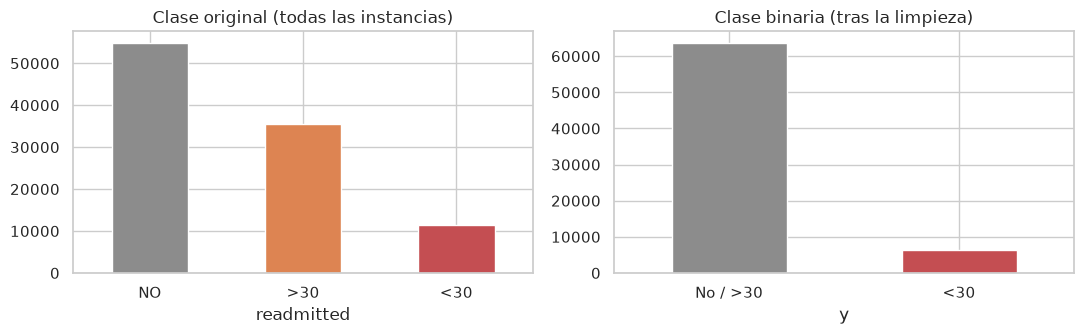

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
df.readmitted.value_counts().reindex(["NO", ">30", "<30"]).plot.bar(ax=axes[0], color=["C7", "C1", "C3"], rot=0)
axes[0].set_title("Clase original (todas las instancias)")
d.y.map({0: "No / >30", 1: "<30"}).value_counts().plot.bar(ax=axes[1], color=["C7", "C3"], rot=0)
axes[1].set_title("Clase binaria (tras la limpieza)")
plt.tight_layout(); plt.show()

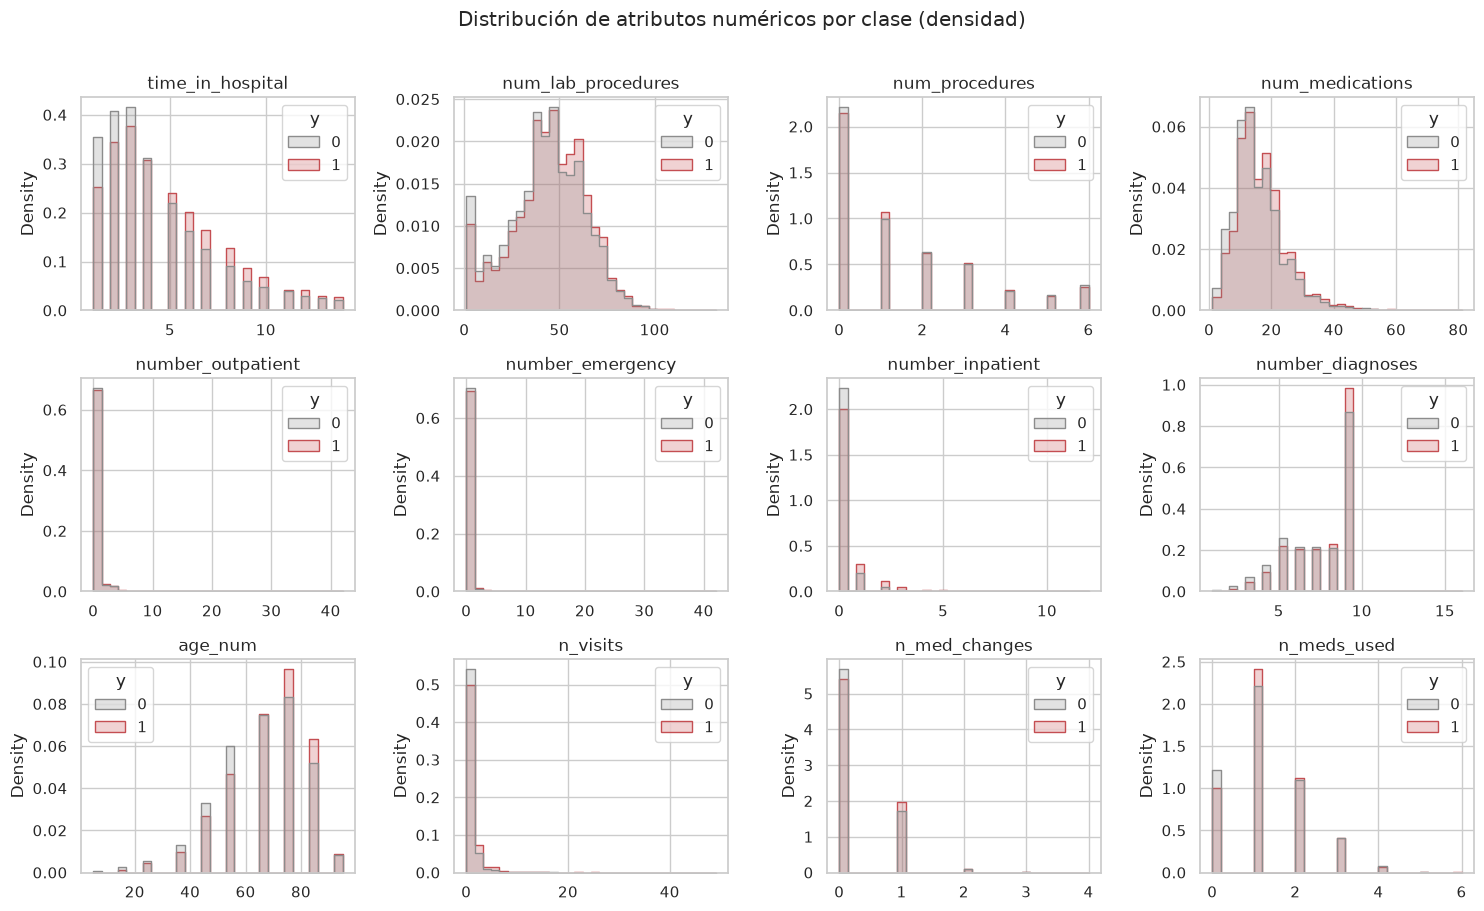

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,69987.0,4.27,2.93,1.0,2.0,3.0,6.0,14.0
num_lab_procedures,69987.0,42.88,19.89,1.0,31.0,44.0,57.0,132.0
num_procedures,69987.0,1.43,1.76,0.0,0.0,1.0,2.0,6.0
num_medications,69987.0,15.67,8.29,1.0,10.0,14.0,20.0,81.0
number_outpatient,69987.0,0.28,1.06,0.0,0.0,0.0,0.0,42.0
number_emergency,69987.0,0.10,0.51,0.0,0.0,0.0,0.0,42.0
number_inpatient,69987.0,0.18,0.60,0.0,0.0,0.0,0.0,12.0
number_diagnoses,69987.0,7.22,2.00,1.0,6.0,8.0,9.0,16.0
age_num,69987.0,65.44,15.97,5.0,55.0,65.0,75.0,95.0
n_visits,69987.0,0.56,1.43,0.0,0.0,0.0,1.0,49.0


In [11]:
fig, axes = plt.subplots(3, 4, figsize=(15, 9))
for ax, c in zip(axes.flat, num_cols):
    sns.histplot(data=d, x=c, hue="y", stat="density", common_norm=False, bins=30, ax=ax,
                 element="step", palette={0: "C7", 1: "C3"})
    ax.set_title(c); ax.set_xlabel("")
plt.suptitle("Distribución de atributos numéricos por clase (densidad)", y=1.01)
plt.tight_layout(); plt.show()
d[num_cols].describe().T.round(2)

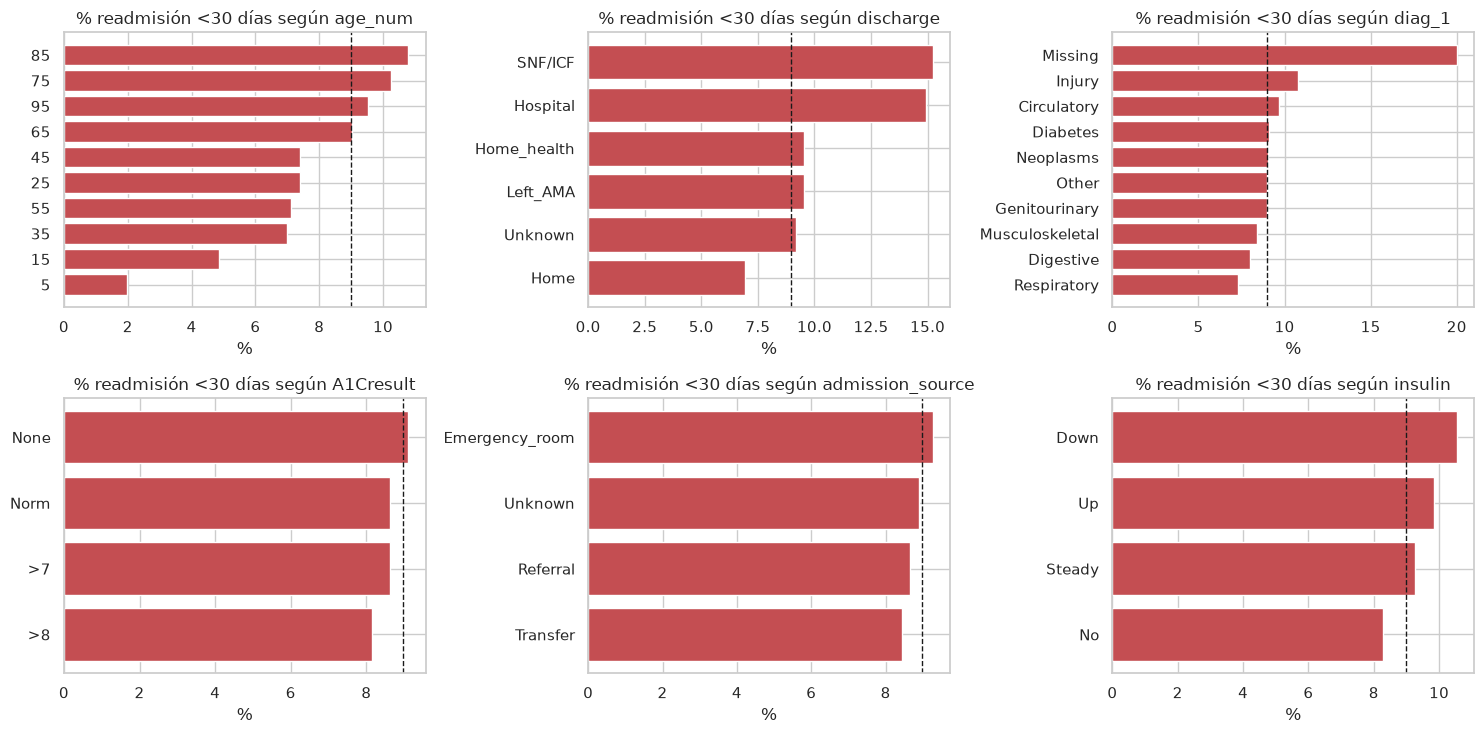

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, c in zip(axes.flat, ["age_num", "discharge", "diag_1", "A1Cresult", "admission_source", "insulin"]):
    r = d.groupby(c).y.agg(["mean", "size"]).sort_values("mean")
    ax.barh(r.index.astype(str), r["mean"] * 100, color="C3")
    ax.axvline(d.y.mean() * 100, ls="--", color="k", lw=1)
    ax.set_title(f"% readmisión <30 días según {c}"); ax.set_xlabel("%")
plt.tight_layout(); plt.show()

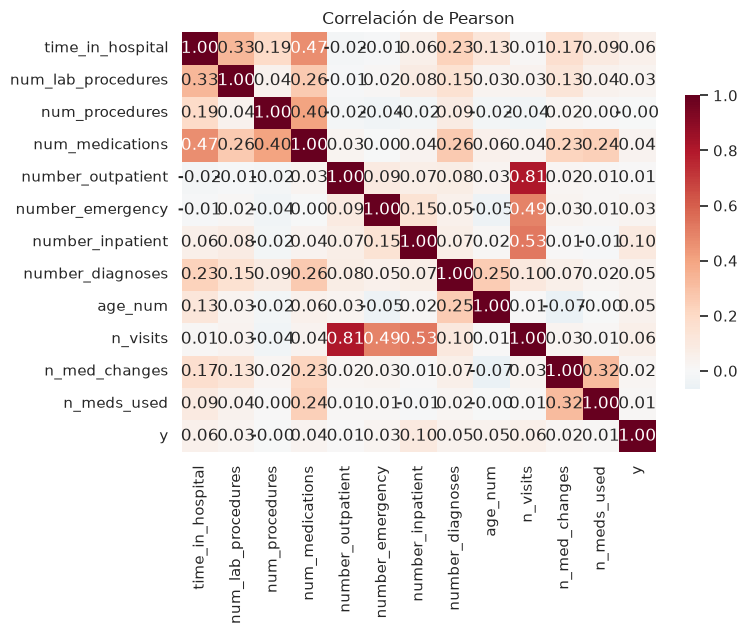

In [13]:
plt.figure(figsize=(8, 6.5))
sns.heatmap(d[num_cols + ["y"]].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, cbar_kws={"shrink": .7})
plt.title("Correlación de Pearson"); plt.tight_layout(); plt.show()

**Observaciones del análisis exploratorio:**
- `number_inpatient` (hospitalizaciones previas) es el atributo individual más relacionado con la readmisión temprana.
- El destino al alta importa: los pacientes trasladados a centros de cuidado (SNF/ICF) u otro hospital se readmiten más que los enviados a casa.
- La edad muestra un gradiente leve; los niveles de HbA1c (`A1Cresult`) diferencian poco.
- Ninguna correlación lineal individual con la clase supera ~0.17: el problema es **difícil**, lo que ya anticipa rendimientos modestos.

### 4.1 Selección de atributos (Cap. 7.1 *Attribute selection*)
El libro presenta evaluadores de atributo individual (*filter methods*) como **ganancia de información** y **χ²**. Usamos la información mutua (equivalente a la ganancia de información) sobre todos los atributos codificados ordinalmente.

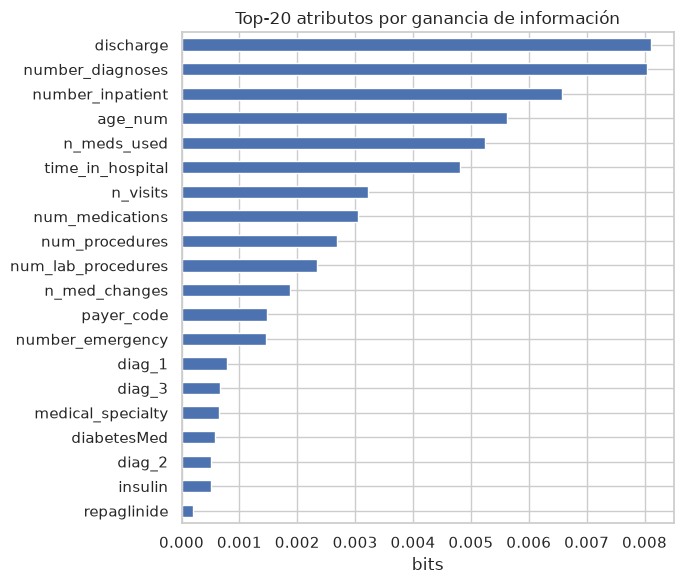

,info_gain (bits),chi2
discharge,0.0081,1698.2653
number_diagnoses,0.0080,80.6892
number_inpatient,0.0066,1444.9706
age_num,0.0056,604.9284
n_meds_used,0.0053,7.0925
time_in_hospital,0.0048,439.3049
n_visits,0.0032,879.0866
num_medications,0.0031,402.0830
num_procedures,0.0027,0.0111
num_lab_procedures,0.0023,663.9409


In [14]:
X_ord = d[num_cols + cat_cols].copy()
X_ord[cat_cols] = OrdinalEncoder().fit_transform(X_ord[cat_cols].astype(str)).astype(int)
disc_mask = [c in cat_cols for c in X_ord.columns]
mi = pd.Series(mutual_info_classif(X_ord, d.y, discrete_features=disc_mask, random_state=SEED),
               index=X_ord.columns)
chi = pd.Series(chi2(X_ord.clip(lower=0), d.y)[0], index=X_ord.columns)
rank = pd.DataFrame({"info_gain (bits)": mi / np.log(2), "chi2": chi}).sort_values("info_gain (bits)", ascending=False)

rank["info_gain (bits)"].head(20).iloc[::-1].plot.barh(figsize=(7, 6), color="C0")
plt.title("Top-20 atributos por ganancia de información"); plt.xlabel("bits"); plt.tight_layout(); plt.show()
rank.head(15).round(4)

El **destino al alta**, el **número de diagnósticos**, las **hospitalizaciones previas** (`number_inpatient`) y la **edad** encabezan el ranking; χ² coincide en destacar `discharge`, `number_inpatient` y `n_visits`. Los valores absolutos de ganancia son muy bajos (< 0.01 bits frente a los 0.44 bits de entropía de la clase): ningún atributo por sí solo es muy predictivo. Muchos medicamentos individuales aportan casi cero información: se consideran candidatos a eliminar para los métodos sensibles a atributos irrelevantes (k-NN, Naive Bayes; ver Cap. 7.1 sobre el efecto negativo de los atributos irrelevantes).

## 5. Métodos básicos de clasificación (Cap. 4)

### 5.1 Protocolo de evaluación (Cap. 5)
- **Validación cruzada estratificada de 10 particiones** (Cap. 5.3), el estándar que recomienda el libro.
- Para comparar esquemas: **t-test pareado corregido** sobre los resultados por partición (Cap. 5.5).
- Métrica principal: **AUC-ROC** (independiente del umbral y del desbalance). También precisión, recall y F1 de la clase positiva.
- Para manejar el desbalance se usa `class_weight="balanced"` (aprendizaje sensible al costo, Cap. 5.7) donde el algoritmo lo permite.

In [15]:
X = d[num_cols + cat_cols]
y = d.y.values
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

onehot = ColumnTransformer([("num", StandardScaler(), num_cols),
                            ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), cat_cols)])
ordinal_tr = ColumnTransformer([("num", "passthrough", num_cols),
                                ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols)])

results, fold_auc = {}, {}
def evaluate(name, model, X_=X):
    r = cross_validate(model, X_, y, cv=cv, n_jobs=-1,
                       scoring=["roc_auc", "accuracy", "precision", "recall", "f1", "average_precision"])
    results[name] = {k.replace("test_", ""): v.mean() for k, v in r.items() if k.startswith("test_")}
    fold_auc[name] = r["test_roc_auc"]
    print(f"{name:<28} AUC={r['test_roc_auc'].mean():.3f} ± {r['test_roc_auc'].std():.3f}  "
          f"Recall={r['test_recall'].mean():.3f}  Prec={r['test_precision'].mean():.3f}  F1={r['test_f1'].mean():.3f}")

### 5.2 ZeroR — línea base
El libro recomienda empezar siempre por la regla más simple: predecir la clase mayoritaria.

In [16]:
evaluate("ZeroR", DummyClassifier(strategy="prior"))
print(f"\nExactitud de ZeroR: {results['ZeroR']['accuracy']:.3%} — sin detectar ni un solo caso positivo.")

ZeroR                        AUC=0.500 ± 0.000  Recall=0.000  Prec=0.000  F1=0.000

Exactitud de ZeroR: 91.020% — sin detectar ni un solo caso positivo.


### 5.3 1R — *Inferring rudimentary rules* (Cap. 4.1)
1R construye una regla por atributo (una rama por valor, clase mayoritaria de cada rama) y elige el atributo con menor error. Los numéricos se discretizan en intervalos con un mínimo de instancias por intervalo. Implementamos la versión del libro, pero, como la clase mayoritaria es "no" en casi todas las ramas, la variante útil elige como regla *"positivo si la tasa de la rama supera la tasa base"* y ordena atributos por AUC.

In [17]:
from sklearn.base import BaseEstimator, ClassifierMixin

class OneR(ClassifierMixin, BaseEstimator):
    '''1R (Holte, 1993) — Cap. 4.1 de DM3. Numéricos discretizados por cuantiles.'''
    def __init__(self, bins=10): self.bins = bins
    def _disc(self, X):
        Z = X.copy()
        for c in self.num_:
            Z[c] = np.digitize(Z[c], self.edges_[c])
        return Z.astype(str)
    def fit(self, X, y):
        self.classes_ = np.array([0, 1])
        self.num_ = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
        self.edges_ = {c: np.unique(np.quantile(X[c], np.linspace(0, 1, self.bins + 1)[1:-1])) for c in self.num_}
        Z, best = self._disc(X), (-1, None, None)
        self.prior_ = y.mean()
        for c in Z.columns:
            rates = pd.Series(y).groupby(Z[c].values).mean()
            auc = roc_auc_score(y, Z[c].map(rates).values)
            if auc > best[0]: best = (auc, c, rates)
        self.auc_, self.attr_, self.rates_ = best
        return self
    def predict_proba(self, X):
        p = self._disc(X)[self.attr_].map(self.rates_).fillna(self.prior_).values
        return np.c_[1 - p, p]
    def predict(self, X): return (self.predict_proba(X)[:, 1] > self.prior_).astype(int)

one_r = OneR().fit(X, y)
print(f"Atributo elegido por 1R: {one_r.attr_}")
print("Regla (tasa de readmisión por valor):")
for v, r in one_r.rates_.sort_index(key=lambda s: s.astype(int) if s.str.isdigit().all() else s).items():
    print(f"   {one_r.attr_} bin {v}: {r:.1%} → {'<30' if r > one_r.prior_ else 'NO'}")
evaluate("1R", OneR())

Atributo elegido por 1R: discharge
Regla (tasa de readmisión por valor):
   discharge bin Home: 6.9% → NO
   discharge bin Home_health: 9.5% → <30
   discharge bin Hospital: 14.9% → <30
   discharge bin Left_AMA: 9.5% → <30
   discharge bin SNF/ICF: 15.2% → <30
   discharge bin Unknown: 9.2% → <30


1R                           AUC=0.590 ± 0.010  Recall=0.501  Prec=0.125  F1=0.200


### 5.4 Naive Bayes (Cap. 4.2 *Statistical modeling*)
Naive Bayes asume independencia condicional de los atributos dada la clase. Se usa la versión categórica: los numéricos se discretizan (Cap. 7.2 *Discretizing numeric attributes*) y se aplica el estimador de Laplace para evitar probabilidades cero. Solo se usan los 20 atributos más informativos, porque los atributos redundantes violan la suposición de independencia.

In [18]:
from sklearn.preprocessing import KBinsDiscretizer
top20 = rank.index[:20].tolist()
nb_num = [c for c in top20 if c in num_cols]; nb_cat = [c for c in top20 if c in cat_cols]
nb = Pipeline([
    ("prep", ColumnTransformer([
        ("num", KBinsDiscretizer(n_bins=8, encode="ordinal", strategy="quantile", subsample=None), nb_num),
        ("cat", OrdinalEncoder(categories=[sorted(X[c].unique()) for c in nb_cat]), nb_cat)])),
    ("clf", CategoricalNB(alpha=1.0, min_categories=40))])
evaluate("Naive Bayes (top-20)", nb, X[top20])

Naive Bayes (top-20)         AUC=0.624 ± 0.011  Recall=0.003  Prec=0.264  F1=0.005


### 5.5 Árboles de decisión (Cap. 4.3 *Divide and conquer* y Cap. 6.1)
Se usa un árbol con criterio de **entropía / ganancia de información** (como ID3/C4.5). Sin poda, el árbol sobreajusta; el libro dedica el Cap. 6.1 a la poda. Aquí se controla con profundidad máxima y un mínimo de instancias por hoja (equivalente al parámetro `-M` de J48).

In [19]:
tree_full = Pipeline([("prep", ordinal_tr), ("clf", DecisionTreeClassifier(criterion="entropy", random_state=SEED))])
tree = Pipeline([("prep", ordinal_tr), ("clf", DecisionTreeClassifier(criterion="entropy", max_depth=6,
                                   min_samples_leaf=100, class_weight="balanced", random_state=SEED))])
evaluate("Árbol sin podar", tree_full)
evaluate("Árbol podado (J48-like)", tree)

Árbol sin podar              AUC=0.524 ± 0.009  Recall=0.149  Prec=0.127  F1=0.137


Árbol podado (J48-like)      AUC=0.631 ± 0.009  Recall=0.554  Prec=0.135  F1=0.217


In [20]:
tree.fit(X, y)
names = num_cols + cat_cols
print(export_text(tree.named_steps["clf"], feature_names=names, max_depth=3, decimals=1))

|--- discharge <= 1.5
|   |--- number_inpatient <= 0.5
|   |   |--- number_diagnoses <= 6.5
|   |   |   |--- diag_1 <= 0.5
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- diag_1 >  0.5
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- number_diagnoses >  6.5
|   |   |   |--- discharge <= 0.5
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- discharge >  0.5
|   |   |   |   |--- truncated branch of depth 3
|   |--- number_inpatient >  0.5
|   |   |--- number_inpatient <= 1.5
|   |   |   |--- admission_type <= 0.5
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- admission_type >  0.5
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- number_inpatient >  1.5
|   |   |   |--- number_inpatient <= 4.5
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- number_inpatient >  4.5
|   |   |   |   |--- class: 1
|--- discharge >  1.5
|   |--- number_inpatient <= 0.5
|   |   |--- discharge <= 4.5
|   |   |   |---

El árbol sin podar tiene AUC ≈ 0.52, apenas mejor que el azar: memoriza el conjunto de entrenamiento y **no generaliza** — ilustración directa del sobreajuste que el libro discute en el Cap. 5.1. El árbol podado es interpretable: la primera división es sobre el destino al alta (casa vs. otros) y la segunda sobre las hospitalizaciones previas (`number_inpatient`).

### 5.6 Modelos lineales: regresión logística (Cap. 4.6)

In [21]:
logreg = Pipeline([("prep", onehot), ("clf", LogisticRegression(max_iter=2000, C=0.1, class_weight="balanced"))])
evaluate("Regresión logística", logreg)

Regresión logística          AUC=0.643 ± 0.011  Recall=0.548  Prec=0.138  F1=0.220


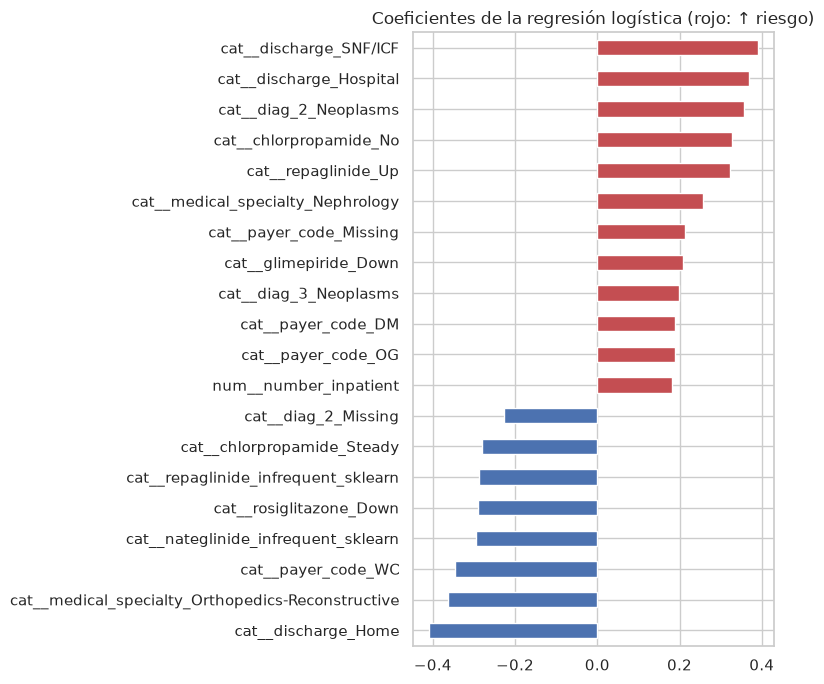

In [22]:
logreg.fit(X, y)
coef = pd.Series(logreg.named_steps["clf"].coef_[0], index=logreg.named_steps["prep"].get_feature_names_out())
top = pd.concat([coef.nlargest(12), coef.nsmallest(8)]).sort_values()
top.plot.barh(figsize=(8, 7), color=np.where(top > 0, "C3", "C0"))
plt.title("Coeficientes de la regresión logística (rojo: ↑ riesgo)"); plt.tight_layout(); plt.show()

### 5.7 Aprendizaje basado en instancias: k-NN (Cap. 4.7)
k-NN requiere normalizar los atributos (Cap. 4.7 *Distance function*) y es sensible a atributos irrelevantes, así que se usa sobre los 20 atributos más informativos. Por su costo computacional se evalúa sobre una muestra estratificada de 20 000 instancias.

In [23]:
Xs, _, ys, _ = train_test_split(X[top20], y, train_size=20000, stratify=y, random_state=SEED)
knn_prep = ColumnTransformer([("num", StandardScaler(), nb_num),
                              ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), nb_cat)])
for k in [5, 25, 75]:
    knn = Pipeline([("prep", knn_prep), ("clf", KNeighborsClassifier(n_neighbors=k))])
    r = cross_validate(knn, Xs, ys, cv=cv, scoring="roc_auc", n_jobs=-1)
    print(f"k={k:<3} AUC={r['test_score'].mean():.3f} ± {r['test_score'].std():.3f}")

k=5   AUC=0.549 ± 0.015


k=25  AUC=0.577 ± 0.022


k=75  AUC=0.598 ± 0.014


Un *k* pequeño es ruidoso; valores grandes suavizan y mejoran el AUC, pero k-NN queda por debajo de los modelos lineales y de árbol para este tipo de datos mixtos y desbalanceados. No se incluye en la comparación final por usar una muestra distinta.

## 6. Métodos de ensamble (Cap. 8)
El libro muestra que combinar modelos (bagging, randomización, boosting) reduce la varianza y/o el sesgo de los árboles.

In [24]:
evaluate("Bagging (árboles)", Pipeline([("prep", ordinal_tr), ("clf", BaggingClassifier(
    DecisionTreeClassifier(min_samples_leaf=50), n_estimators=100, random_state=SEED, n_jobs=-1))]))
evaluate("Random Forest", Pipeline([("prep", ordinal_tr), ("clf", RandomForestClassifier(
    n_estimators=300, min_samples_leaf=20, max_features="sqrt", class_weight="balanced_subsample",
    random_state=SEED, n_jobs=-1))]))
evaluate("AdaBoost (stumps)", Pipeline([("prep", ordinal_tr), ("clf", AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators=300, learning_rate=0.5, random_state=SEED))]))
cat_idx = list(range(len(num_cols), len(num_cols) + len(cat_cols)))
evaluate("Gradient Boosting", Pipeline([("prep", ordinal_tr), ("clf", HistGradientBoostingClassifier(
    learning_rate=0.05, max_iter=300, max_leaf_nodes=15, min_samples_leaf=100, l2_regularization=1.0,
    categorical_features=cat_idx, class_weight="balanced", random_state=SEED))]))

Bagging (árboles)            AUC=0.648 ± 0.011  Recall=0.000  Prec=0.000  F1=0.000


Random Forest                AUC=0.652 ± 0.011  Recall=0.299  Prec=0.188  F1=0.231


AdaBoost (stumps)            AUC=0.640 ± 0.011  Recall=0.000  Prec=0.000  F1=0.000


Gradient Boosting            AUC=0.653 ± 0.010  Recall=0.560  Prec=0.139  F1=0.223


Bagging y AdaBoost (igual que Naive Bayes) se entrenaron **sin** ponderación de costos: su AUC es competitivo (ordenan bien a los pacientes por riesgo), pero con el umbral por defecto de 0.5 nunca predicen la clase minoritaria (recall = 0). Es exactamente el fenómeno que el libro describe en el Cap. 5.7: con clases desbalanceadas hay que ajustar el umbral o los costos, no solo el algoritmo.

## 7. Credibilidad: ¿qué tan bueno es lo aprendido? (Cap. 5)

### 7.1 Tabla comparativa

In [25]:
res = pd.DataFrame(results).T[["roc_auc", "average_precision", "accuracy", "precision", "recall", "f1"]]
res.columns = ["AUC-ROC", "AUC-PR", "Exactitud", "Precisión", "Recall", "F1"]
res.sort_values("AUC-ROC", ascending=False).style.format("{:.3f}").background_gradient(subset=["AUC-ROC", "F1"], cmap="Greens")

,AUC-ROC,AUC-PR,Exactitud,Precisión,Recall,F1
Gradient Boosting,0.653,0.167,0.650,0.139,0.560,0.223
Random Forest,0.652,0.164,0.821,0.188,0.299,0.231
Bagging (árboles),0.648,0.168,0.910,0.000,0.000,0.000
Regresión logística,0.643,0.157,0.651,0.138,0.548,0.220
AdaBoost (stumps),0.640,0.155,0.910,0.000,0.000,0.000
Árbol podado (J48-like),0.631,0.148,0.642,0.135,0.554,0.217
Naive Bayes (top-20),0.624,0.135,0.910,0.264,0.003,0.005
1R,0.590,0.117,0.639,0.125,0.501,0.200
Árbol sin podar,0.524,0.096,0.832,0.127,0.149,0.137
ZeroR,0.500,0.090,0.910,0.000,0.000,0.000


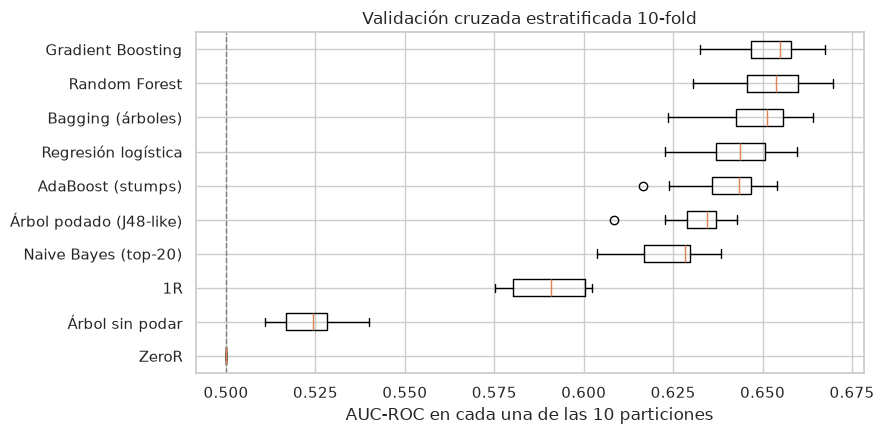

In [26]:
order = pd.Series({k: v.mean() for k, v in fold_auc.items()}).sort_values().index
plt.figure(figsize=(9, 4.5))
plt.boxplot([fold_auc[k] for k in order], orientation="horizontal", tick_labels=order)
plt.axvline(0.5, ls="--", color="grey", lw=1)
plt.xlabel("AUC-ROC en cada una de las 10 particiones"); plt.title("Validación cruzada estratificada 10-fold")
plt.tight_layout(); plt.show()

### 7.2 Comparación estadística de esquemas: t-test pareado corregido (Cap. 5.5)
Las particiones de la validación cruzada no son independientes (comparten datos de entrenamiento), por lo que el libro recomienda el **t-test corregido** de Nadeau y Bengio, que infla la varianza por el factor $\left(\frac{1}{k} + \frac{n_2}{n_1}\right)$.

In [27]:
def corrected_ttest(a, b, n_train_over_test=9):
    diff = a - b; k = len(diff)
    t = diff.mean() / np.sqrt((1 / k + 1 / n_train_over_test) * diff.var(ddof=1))
    return t, 2 * stats.t.sf(abs(t), k - 1)

best = res["AUC-ROC"].idxmax()
print(f"Mejor esquema: {best}\n")
rows = []
for m in res.index:
    if m == best: continue
    t, p = corrected_ttest(fold_auc[best], fold_auc[m])
    rows.append({"vs": m, "ΔAUC": fold_auc[best].mean() - fold_auc[m].mean(), "t": t, "p-valor": p,
                 "¿significativo (α=0.05)?": "sí" if p < 0.05 else "no"})
pd.DataFrame(rows).set_index("vs").round(4)

Mejor esquema: Gradient Boosting



,ΔAUC,t,p-valor,¿significativo (α=0.05)?
vs,,,,
ZeroR,0.1532,32.3809,0.0000,sí
1R,0.0631,17.4845,0.0000,sí
Naive Bayes (top-20),0.0293,6.9585,0.0001,sí
Árbol sin podar,0.1293,28.4003,0.0000,sí
Árbol podado (J48-like),0.0218,12.9710,0.0000,sí
Regresión logística,0.0101,4.1405,0.0025,sí
Bagging (árboles),0.0050,1.9364,0.0848,no
Random Forest,0.0008,0.5943,0.5670,no
AdaBoost (stumps),0.0132,6.5807,0.0001,sí


### 7.3 Matriz de confusión, ROC, precisión-recall y lift (Cap. 5.7)
Se obtienen predicciones *out-of-fold* (cada instancia predicha por el modelo que no la vio) para el mejor modelo y la regresión logística.

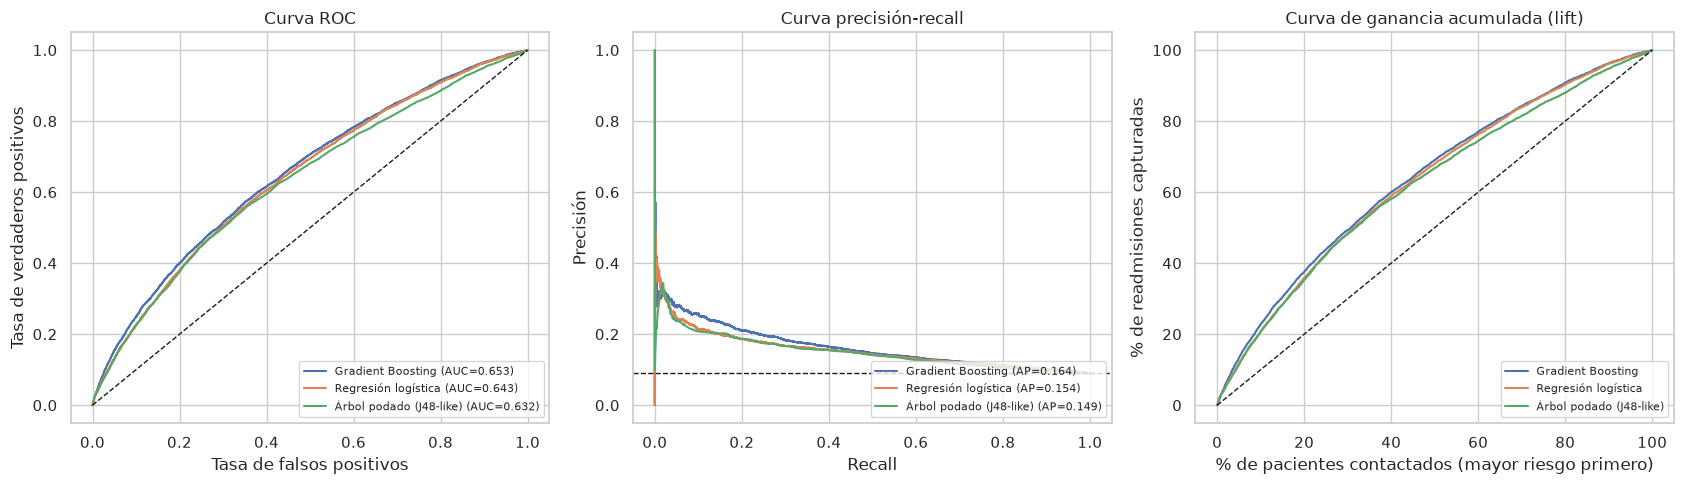

Top 10% de riesgo → captura 22.8% de las readmisiones (lift = 2.28)
Top 20% de riesgo → captura 37.5% de las readmisiones (lift = 1.87)
Top 30% de riesgo → captura 49.4% de las readmisiones (lift = 1.65)


In [28]:
models_cv = {
    "Gradient Boosting": Pipeline([("prep", ordinal_tr), ("clf", HistGradientBoostingClassifier(
        learning_rate=0.05, max_iter=300, max_leaf_nodes=15, min_samples_leaf=100, l2_regularization=1.0,
        categorical_features=cat_idx, class_weight="balanced", random_state=SEED))]),
    "Regresión logística": logreg,
    "Árbol podado (J48-like)": tree,
}
oof = {n: cross_val_predict(m, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1] for n, m in models_cv.items()}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for i, (n, p) in enumerate(oof.items()):
    fpr, tpr, _ = roc_curve(y, p); axes[0].plot(fpr, tpr, label=f"{n} (AUC={roc_auc_score(y, p):.3f})", color=f"C{i}")
    pr, rc, _ = precision_recall_curve(y, p); axes[1].plot(rc, pr, label=f"{n} (AP={average_precision_score(y, p):.3f})", color=f"C{i}")
    o = np.argsort(-p); cum = np.cumsum(y[o]) / y.sum(); frac = np.arange(1, len(y) + 1) / len(y)
    axes[2].plot(frac * 100, cum * 100, label=n, color=f"C{i}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1); axes[0].set(xlabel="Tasa de falsos positivos", ylabel="Tasa de verdaderos positivos", title="Curva ROC")
axes[1].axhline(y.mean(), ls="--", color="k", lw=1); axes[1].set(xlabel="Recall", ylabel="Precisión", title="Curva precisión-recall")
axes[2].plot([0, 100], [0, 100], "k--", lw=1); axes[2].set(xlabel="% de pacientes contactados (mayor riesgo primero)",
             ylabel="% de readmisiones capturadas", title="Curva de ganancia acumulada (lift)")
for a in axes: a.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

p = oof["Gradient Boosting"]; o = np.argsort(-p)
for pct in [10, 20, 30]:
    k = int(len(y) * pct / 100); cap = y[o[:k]].sum() / y.sum()
    print(f"Top {pct}% de riesgo → captura {cap:.1%} de las readmisiones (lift = {cap / (pct/100):.2f})")

### 7.4 Aprendizaje sensible al costo: elección del umbral (Cap. 5.7 *Cost-sensitive classification*)
Supongamos un escenario ilustrativo: una readmisión no detectada (falso negativo) cuesta **10 unidades** (costo promedio de una rehospitalización), mientras que una intervención preventiva innecesaria (falso positivo, p. ej. una llamada de seguimiento o visita domiciliaria) cuesta **1 unidad**. El umbral óptimo minimiza el costo total esperado.

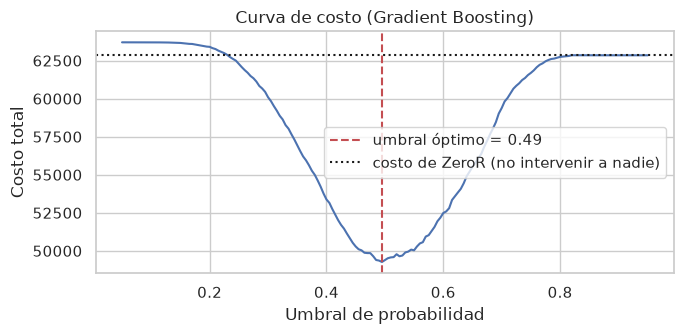

Costo con umbral óptimo: 49,271  vs. ZeroR: 62,850  (ahorro 21.6%)

           Pred: No  Pred: <30
Real: No      41111      22591
Real: <30      2668       3617

               precision    recall  f1-score   support

    No / >30      0.939     0.645     0.765     63702
         <30      0.138     0.575     0.223      6285

    accuracy                          0.639     69987
   macro avg      0.539     0.610     0.494     69987
weighted avg      0.867     0.639     0.716     69987



In [29]:
C_FN, C_FP = 10, 1
ths = np.linspace(0.05, 0.95, 181)
costs = [C_FN * ((p < t) & (y == 1)).sum() + C_FP * ((p >= t) & (y == 0)).sum() for t in ths]
t_best = ths[int(np.argmin(costs))]
cost_zero_r = C_FN * y.sum()

plt.figure(figsize=(7, 3.5))
plt.plot(ths, costs); plt.axvline(t_best, ls="--", color="C3", label=f"umbral óptimo = {t_best:.2f}")
plt.axhline(cost_zero_r, ls=":", color="k", label="costo de ZeroR (no intervenir a nadie)")
plt.xlabel("Umbral de probabilidad"); plt.ylabel("Costo total"); plt.legend(); plt.title("Curva de costo (Gradient Boosting)")
plt.tight_layout(); plt.show()

pred = (p >= t_best).astype(int)
cm = confusion_matrix(y, pred)
print(f"Costo con umbral óptimo: {min(costs):,}  vs. ZeroR: {cost_zero_r:,}  (ahorro {1 - min(costs)/cost_zero_r:.1%})\n")
print(pd.DataFrame(cm, index=["Real: No", "Real: <30"], columns=["Pred: No", "Pred: <30"]))
print("\n", classification_report(y, pred, target_names=["No / >30", "<30"], digits=3))

### 7.5 Importancia de atributos en el mejor modelo
Importancia por permutación sobre un conjunto de prueba separado: cuánto baja el AUC al desordenar cada atributo.

AUC en prueba (hold-out 30%): 0.656


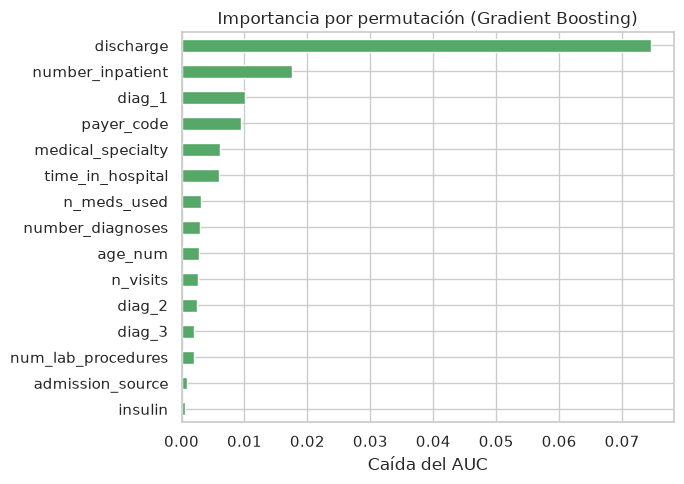

In [30]:
from sklearn.inspection import permutation_importance
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=SEED)
gb = models_cv["Gradient Boosting"].fit(Xtr, ytr)
print(f"AUC en prueba (hold-out 30%): {roc_auc_score(yte, gb.predict_proba(Xte)[:, 1]):.3f}")
pi = permutation_importance(gb, Xte, yte, scoring="roc_auc", n_repeats=5, random_state=SEED, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X.columns).sort_values(ascending=False).head(15)
imp.iloc[::-1].plot.barh(figsize=(7, 5), color="C2"); plt.xlabel("Caída del AUC")
plt.title("Importancia por permutación (Gradient Boosting)"); plt.tight_layout(); plt.show()

## 8. Reglas de asociación (Cap. 4.5 *Mining association rules*)
Apriori busca conjuntos de ítems frecuentes y genera reglas con alta **confianza**. Se construye una tabla transaccional con atributos nominales y numéricos discretizados, y se buscan reglas cuyo consecuente sea `readmitido<30`. Como la clase positiva es rara, se usa soporte mínimo bajo y se ordena por **lift** (confianza / confianza esperada).

In [31]:
from mlxtend.frequent_patterns import apriori, association_rules

tr = pd.DataFrame({
    "inpatient": pd.cut(d.number_inpatient, [-1, 0, 1, 2, 100], labels=["0", "1", "2", "3+"]),
    "emergency": pd.cut(d.number_emergency, [-1, 0, 100], labels=["0", "1+"]),
    "time_hosp": pd.cut(d.time_in_hospital, [0, 3, 7, 14], labels=["1-3d", "4-7d", "8-14d"]),
    "n_diag":    pd.cut(d.number_diagnoses, [0, 6, 8, 16], labels=["≤6", "7-8", "9+"]),
    "age":       pd.cut(d.age_num, [0, 45, 65, 80, 100], labels=["<45", "45-65", "65-80", "80+"]),
    "discharge": d.discharge, "diag_1": d.diag_1, "A1C": d.A1Cresult, "insulin": d.insulin,
    "change": d.change, "adm_source": d.admission_source,
}).astype(str)
basket = pd.get_dummies(tr, prefix_sep="=").astype(bool)
basket["readmitido<30"] = d.y.astype(bool).values

freq = apriori(basket, min_support=0.005, max_len=4, use_colnames=True)
rules = association_rules(freq, metric="lift", min_threshold=1.5)
rules = rules[rules.consequents == frozenset({"readmitido<30"})]
rules = rules.sort_values(["lift", "support"], ascending=False)
fmt = lambda s: " ∧ ".join(sorted(s))
out = rules.assign(regla=rules.antecedents.map(fmt))[["regla", "support", "confidence", "lift"]]
print(f"{len(freq)} conjuntos frecuentes, {len(out)} reglas con consecuente 'readmitido<30' y lift ≥ 1.5")
out.head(15).round(3).reset_index(drop=True)

19026 conjuntos frecuentes, 78 reglas con consecuente 'readmitido<30' y lift ≥ 1.5


,regla,support,confidence,lift
0,discharge=SNF/ICF ∧ emergency=0 ∧ n_diag=≤6,0.006,0.179,1.992
1,diag_1=Circulatory ∧ discharge=SNF/ICF ∧ emerg...,0.007,0.178,1.987
2,discharge=SNF/ICF ∧ n_diag=≤6,0.006,0.178,1.987
3,age=45-65 ∧ discharge=SNF/ICF ∧ emergency=0,0.007,0.177,1.971
4,A1C=None ∧ age=45-65 ∧ discharge=SNF/ICF,0.006,0.176,1.960
5,age=45-65 ∧ discharge=SNF/ICF,0.007,0.175,1.947
6,diag_1=Circulatory ∧ discharge=SNF/ICF,0.007,0.174,1.940
7,A1C=None ∧ discharge=SNF/ICF ∧ n_diag=≤6,0.005,0.173,1.924
8,age=65-80 ∧ discharge=SNF/ICF ∧ emergency=0,0.008,0.170,1.897
9,age=65-80 ∧ discharge=SNF/ICF,0.009,0.170,1.893


Las reglas con mayor *lift* giran en torno al **alta a centros de cuidado (SNF/ICF)**, combinada con edad media-alta o diagnóstico principal circulatorio: en esos subgrupos la readmisión temprana es ≈ 2 veces la tasa base. Más abajo en la lista aparecen reglas con **hospitalizaciones previas**. Son patrones directamente accionables para priorizar seguimiento.

## 9. Clustering (Cap. 4.8 *Clustering*)
k-means sobre los atributos numéricos estandarizados, para buscar perfiles de pacientes sin usar la clase. El número de grupos se elige con el coeficiente de silueta (sobre una muestra).

In [32]:
cl_cols = ["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
           "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses", "age_num", "n_meds_used"]
Z = StandardScaler().fit_transform(np.log1p(d[cl_cols]))
rng = np.random.default_rng(SEED); samp = rng.choice(len(Z), 8000, replace=False)
sil = {}
for k in range(2, 8):
    km = KMeans(k, n_init=10, random_state=SEED).fit(Z)
    sil[k] = silhouette_score(Z[samp], km.labels_[samp])
print({k: round(v, 3) for k, v in sil.items()})

{2: 0.137, 3: 0.147, 4: 0.122, 5: 0.163, 6: 0.144, 7: 0.151}


k elegido por silueta: 5


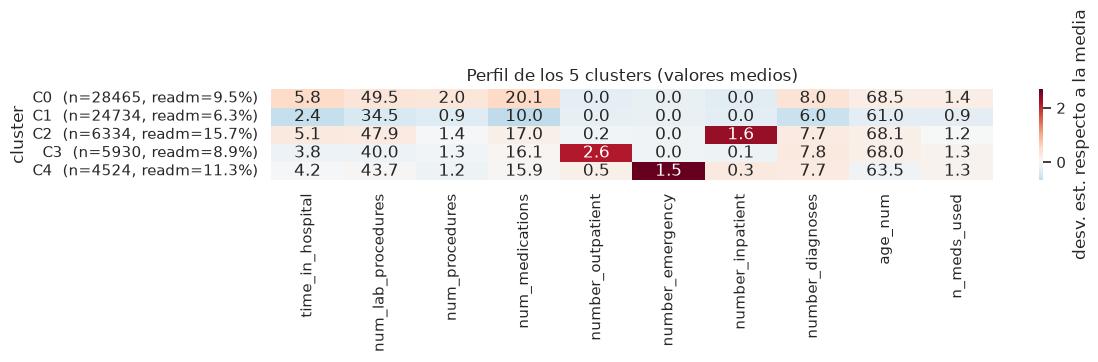

,n,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age_num,n_meds_used,% readm <30
cluster,,,,,,,,,,,,
0,28465,5.81,49.52,2.00,20.12,0.02,0.00,0.00,7.96,68.46,1.38,9.47
1,24734,2.42,34.46,0.87,10.04,0.03,0.00,0.01,6.03,61.02,0.93,6.29
2,6334,5.07,47.89,1.37,17.04,0.18,0.04,1.57,7.72,68.08,1.19,15.72
3,5930,3.84,40.04,1.26,16.08,2.57,0.04,0.10,7.77,68.03,1.27,8.89
4,4524,4.19,43.73,1.18,15.92,0.46,1.48,0.34,7.71,63.53,1.28,11.27


In [33]:
K = max(sil, key=sil.get)
print("k elegido por silueta:", K)
km = KMeans(K, n_init=10, random_state=SEED).fit(Z)
d["cluster"] = km.labels_
prof = d.groupby("cluster")[cl_cols + ["y"]].mean()
prof.insert(0, "n", d.cluster.value_counts().sort_index())
prof = prof.rename(columns={"y": "% readm <30"}); prof["% readm <30"] *= 100

fig, ax = plt.subplots(figsize=(12, 3.2))
sns.heatmap((prof[cl_cols] - d[cl_cols].mean()) / d[cl_cols].std(), annot=prof[cl_cols].round(1), fmt="",
            cmap="RdBu_r", center=0, ax=ax, cbar_kws={"label": "desv. est. respecto a la media"})
ax.set_yticklabels([f"C{i}  (n={n}, readm={r:.1f}%)" for i, (n, r) in enumerate(zip(prof.n, prof['% readm <30']))], rotation=0)
plt.title(f"Perfil de los {K} clusters (valores medios)"); plt.tight_layout(); plt.show()
prof.round(2)

Los grupos separan pacientes por **intensidad de uso previo de servicios** y **complejidad de la hospitalización**. El cluster con más visitas previas (hospitalarias y de urgencias) presenta una tasa de readmisión temprana claramente superior a la media, lo que confirma —sin supervisión— el hallazgo de la clasificación y de las reglas de asociación.

## 10. Conclusiones

1. **Preparación de datos** (Cap. 2 y 7): se detectaron faltantes con significado (`None` en pruebas de laboratorio), atributos inutilizables (`weight`), valores imposibles (pacientes fallecidos con posible readmisión) y — lo más importante — **instancias no independientes** (varios encuentros por paciente), que habrían inflado artificialmente las métricas.
2. **Dificultad del problema:** la readmisión a 30 días depende de muchos factores no registrados (apoyo social, adherencia, etc.). Los mejores modelos alcanzan un AUC ≈ 0.65, en línea con lo publicado para este dataset.
3. **Comparación de esquemas** (Cap. 5): ZeroR tiene la mayor exactitud (~91 %) pero es inútil; por eso se usaron AUC, recall y análisis de costo. **Gradient Boosting** y **Random Forest** son los mejores (sin diferencia significativa entre ellos según el t-test corregido), seguidos de la regresión logística; el árbol sin podar sobreajusta (AUC ≈ 0.52), mostrando la necesidad de poda.
4. **Ensambles** (Cap. 8): boosting y random forest mejoran al árbol individual, como predice el libro.
5. **Valor práctico:** bajo un costo 10:1 (FN:FP), usar el modelo reduce el costo total respecto a no intervenir; contactando al 20 % de mayor riesgo se captura una proporción de readmisiones claramente superior al azar.
6. **Patrones consistentes** entre clasificación, reglas de asociación y clustering: los factores dominantes son el **destino al alta** (centros de cuidado / otro hospital), el **número de hospitalizaciones previas y visitas a urgencias**, el **número de diagnósticos** y la **edad**.

**Trabajo futuro:** incorporar el historial completo del paciente como atributos agregados (en lugar de descartar encuentros posteriores), probar selección de atributos *wrapper* (Cap. 7.1), calibrar probabilidades (Cap. 7.7) y validar con datos más recientes.